AND GATE SINGLE PERCEPTRON HARD-CODED WEIGHTS
 Weights: W1=1.0, W2=1.0
 Bias: b=-1.5
 Equation: 1.0x1 + 1.0x2 + -1.5 > 0

PREDICTIONS
[0, 0] → Linear:  -1.5 → Pred: 0 | Actual: 0
[0, 1] → Linear:  -0.5 → Pred: 0 | Actual: 0
[1, 0] → Linear:  -0.5 → Pred: 0 | Actual: 0
[1, 1] → Linear:   0.5 → Pred: 1 | Actual: 1


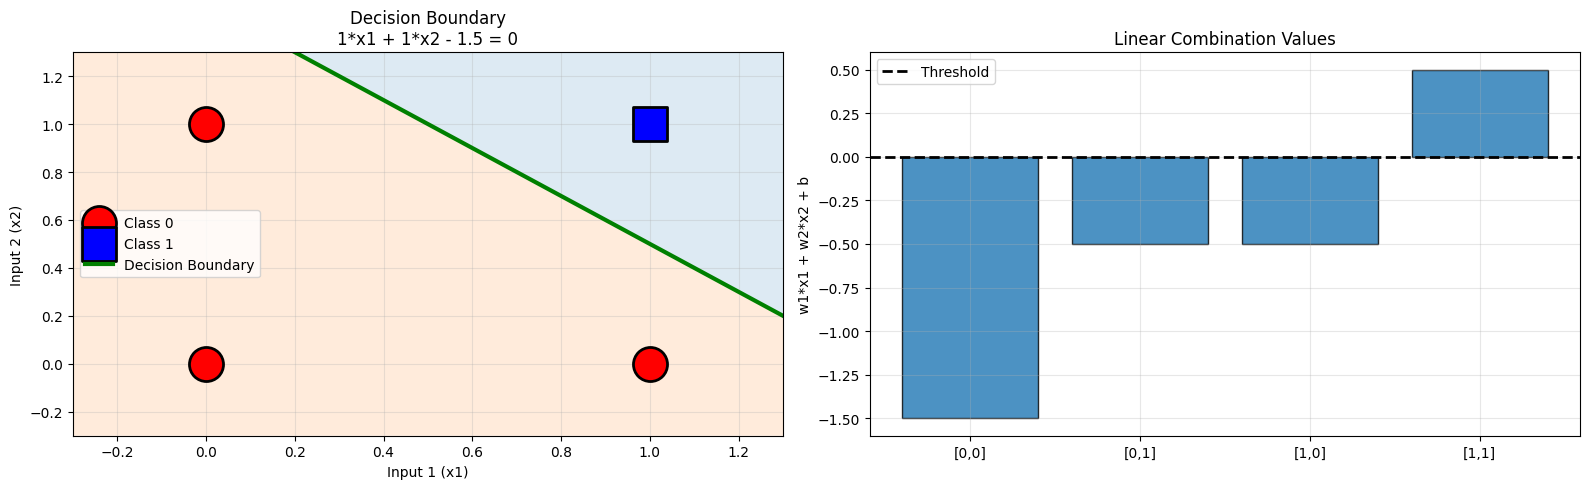


VERIFICATION RESULTS:
 Decision boundary (solved for x2): x2 = (-1.0*x1 - (-1.5)) / 1.0
Linear values for each input:
 [0, 0]: 1*0 + 1*0 - 1.5 = -1.5
  -> Class 0 (<=0)
 [0, 1]: 1*0 + 1*1 - 1.5 = -0.5
  -> Class 0 (<=0)
 [1, 0]: 1*1 + 1*0 - 1.5 = -0.5
  -> Class 0 (<=0)
 [1, 1]: 1*1 + 1*1 - 1.5 = 0.5
  -> Class 1 (>0)

Point positions relative to boundary:
 [0, 0]: -1.500 → Below (Class 0)
 [0, 1]: -0.500 → Below (Class 0)
 [1, 0]: -0.500 → Below (Class 0)
 [1, 1]: 0.500 → Above (Class 1)


In [ ]:
#AND( HARD CODED)
import numpy as np
import matplotlib.pyplot as plt

# Data for AND gate
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [0], [0], [1]])

print("AND GATE SINGLE PERCEPTRON HARD-CODED WEIGHTS")
print("=" * 60)

# Weights and bias (hard-coded for AND)
weights = np.array([[1.0], [1.0]])
bias = np.array([[-1.5]])

print(f" Weights: W1={weights[0,0]:.1f}, W2={weights[1,0]:.1f}")
print(f" Bias: b={bias[0,0]:.1f}")
print(f" Equation: {weights[0,0]:.1f}x1 + {weights[1,0]:.1f}x2 + {bias[0,0]:.1f} > 0")

def step_function(x):
    return 1 if x > 0 else 0

def perceptron_predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    # return as integers 0/1
    return (linear > 0).astype(int)

def sigmoid_predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    # clip to avoid overflow
    return 1 / (1 + np.exp(-np.clip(linear, -250, 250)))

print("\nPREDICTIONS")
linear_values = np.dot(X, weights) + bias
predictions = perceptron_predict(X, weights, bias)

for i in range(len(X)):
    linear_val = linear_values[i, 0]
    pred = predictions[i, 0]
    actual = y[i, 0]
    print(f"[{X[i,0]:.0f}, {X[i,1]:.0f}] → Linear: {linear_val:5.1f} → Pred: {int(pred)} | Actual: {int(actual)}")

# Plot decision boundary and points
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1],
            s=600, c='red', marker='o', edgecolors='black', linewidth=2, label='Class 0', zorder=3)
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1],
            s=600, c='blue', marker='s', edgecolors='black', linewidth=2, label='Class 1', zorder=4)

x1_range = np.linspace(-0.3, 1.3, 200)
# decision boundary: w1*x1 + w2*x2 + b = 0  -> x2 = (-w1*x1 - b) / w2
x2_boundary = (-weights[0,0] * x1_range - bias[0,0]) / weights[1,0]

plt.plot(x1_range, x2_boundary, 'g-', linewidth=3, label='Decision Boundary', zorder=2)
plt.fill_between(x1_range, x2_boundary, 1.3, alpha=0.15)
plt.fill_between(x1_range, -0.3, x2_boundary, alpha=0.15)
plt.xlim(-0.3, 1.3)
plt.ylim(-0.3, 1.3)
plt.xlabel('Input 1 (x1)')
plt.ylabel('Input 2 (x2)')
plt.title('Decision Boundary\n1*x1 + 1*x2 - 1.5 = 0')
plt.grid(True, alpha=0.3)
plt.legend()

# Bar plot of linear values
plt.subplot(1, 2, 2)
samples = ['[0,0]', '[0,1]', '[1,0]', '[1,1]']
linear_vals = linear_values.flatten()
plt.bar(samples, linear_vals, alpha=0.8, edgecolor='black', linewidth=1)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Threshold')
plt.ylabel('w1*x1 + w2*x2 + b')
plt.title('Linear Combination Values')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Verification prints
print("\nVERIFICATION RESULTS:")
print(f" Decision boundary (solved for x2): x2 = (-{weights[0,0]:.1f}*x1 - ({bias[0,0]:.1f})) / {weights[1,0]:.1f}")
print("Linear values for each input:")
for i in range(4):
    z = weights[0,0]*X[i,0] + weights[1,0]*X[i,1] + bias[0,0]
    print(f" [{X[i,0]:.0f}, {X[i,1]:.0f}]: 1*{X[i,0]:.0f} + 1*{X[i,1]:.0f} - 1.5 = {z:.1f}")
    print(f"  -> {'Class 1 (>0)' if z > 0 else 'Class 0 (<=0)'}")

print("\nPoint positions relative to boundary:")
for i in range(len(X)):
    point_value = weights[0,0]*X[i,0] + weights[1,0]*X[i,1] + bias[0,0]
    side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)"
    print(f" [{X[i,0]:.0f}, {X[i,1]:.0f}]: {point_value:.3f} → {side}")

OR GATE SINGLE PERCEPTRON - HARD-CODED WEIGHTS
 Weights: W1=1.0, W2=1.0
 Bias: b=-0.5
 Equation: 1.0x1 + 1.0x2 + -0.5 > 0

PREDICTIONS
[0, 0] → Linear:  -0.5 → Pred: 0 | Actual: 0
[0, 1] → Linear:   0.5 → Pred: 1 | Actual: 1
[1, 0] → Linear:   0.5 → Pred: 1 | Actual: 1
[1, 1] → Linear:   1.5 → Pred: 1 | Actual: 1


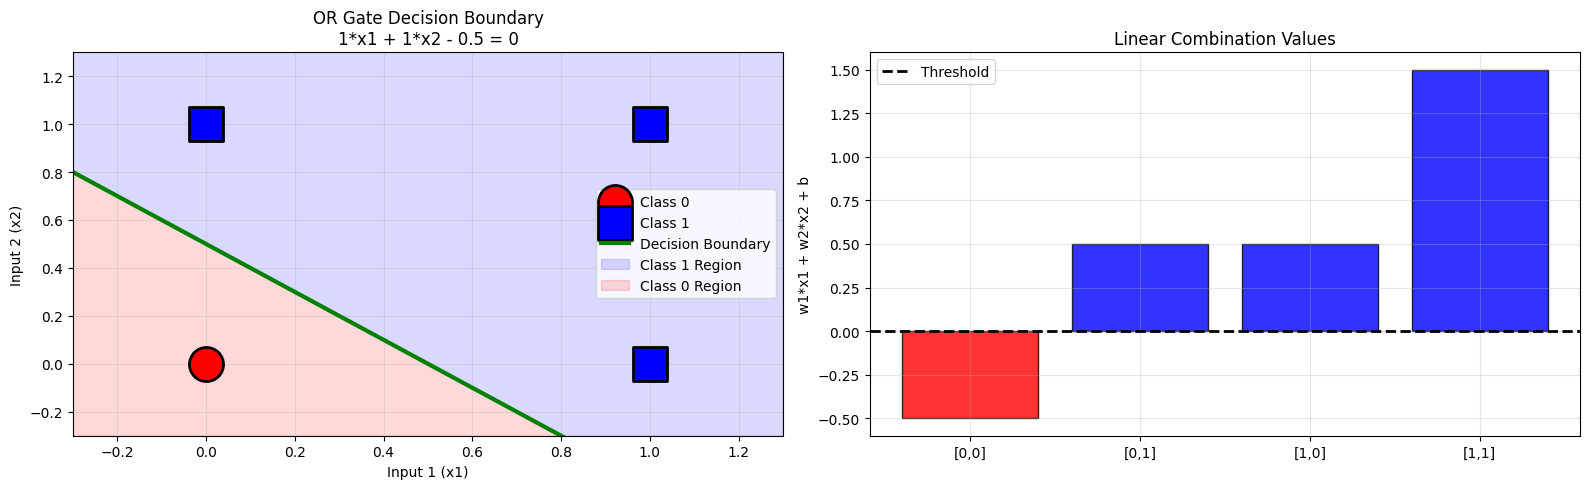


VERIFICATION RESULTS:
 Decision boundary (solved for x2): x2 = (-1.0*x1 - (-0.5)) / 1.0
Linear values for each input:
 [0, 0]: 1*0 + 1*0 - 0.5 = -0.5
  -> Class 0 (<=0)
 [0, 1]: 1*0 + 1*1 - 0.5 = 0.5
  -> Class 1 (>0)
 [1, 0]: 1*1 + 1*0 - 0.5 = 0.5
  -> Class 1 (>0)
 [1, 1]: 1*1 + 1*1 - 0.5 = 1.5
  -> Class 1 (>0)

Point positions relative to boundary:
 [0, 0]: -0.500 → Below (Class 0)
 [0, 1]: 0.500 → Above (Class 1)
 [1, 0]: 0.500 → Above (Class 1)
 [1, 1]: 1.500 → Above (Class 1)


In [ ]:
#OR WITH HARD CODED WEIGHTS
import numpy as np
import matplotlib.pyplot as plt

# Data for OR gate
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [1]])

print("OR GATE SINGLE PERCEPTRON - HARD-CODED WEIGHTS")
print("=" * 60)

# Weights and bias (hard-coded for OR)
weights = np.array([[1.0], [1.0]])
bias = np.array([[-0.5]])

print(f" Weights: W1={weights[0,0]:.1f}, W2={weights[1,0]:.1f}")
print(f" Bias: b={bias[0,0]:.1f}")
print(f" Equation: {weights[0,0]:.1f}x1 + {weights[1,0]:.1f}x2 + {bias[0,0]:.1f} > 0")

def step_function(x):
    return 1 if x > 0 else 0

def perceptron_predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    return (linear > 0).astype(int)

print("\nPREDICTIONS")
linear_values = np.dot(X, weights) + bias
predictions = perceptron_predict(X, weights, bias)

for i in range(len(X)):
    linear_val = linear_values[i, 0]
    pred = predictions[i, 0]
    actual = y[i, 0]
    print(f"[{X[i,0]:.0f}, {X[i,1]:.0f}] → Linear: {linear_val:5.1f} → Pred: {int(pred)} | Actual: {int(actual)}")

# Plot decision boundary and points
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1],
            s=600, marker='o', edgecolors='black', linewidth=2, label='Class 0', zorder=3, color='red')
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1],
            s=600, marker='s', edgecolors='black', linewidth=2, label='Class 1', zorder=4, color='blue')

x1_range = np.linspace(-0.3, 1.3, 200)
w1, w2, b = weights[0,0], weights[1,0], bias[0,0]
# decision boundary: w1*x1 + w2*x2 + b = 0  -> x2 = (-w1*x1 - b) / w2
x2_boundary = (-w1 * x1_range - b) / w2

plt.plot(x1_range, x2_boundary, 'g-', linewidth=3, label='Decision Boundary', zorder=2)
plt.fill_between(x1_range, x2_boundary, 1.3, alpha=0.15, color='blue', label='Class 1 Region')
plt.fill_between(x1_range, -0.3, x2_boundary, alpha=0.15, color='red', label='Class 0 Region')

plt.xlim(-0.3, 1.3)
plt.ylim(-0.3, 1.3)
plt.xlabel('Input 1 (x1)')
plt.ylabel('Input 2 (x2)')
plt.title('OR Gate Decision Boundary\n1*x1 + 1*x2 - 0.5 = 0')
plt.grid(True, alpha=0.3)
plt.legend()

# Bar plot of linear values
plt.subplot(1, 2, 2)
samples = ['[0,0]', '[0,1]', '[1,0]', '[1,1]']
linear_vals = linear_values.flatten()
colors = ['red' if y[i,0] == 0 else 'blue' for i in range(len(y))]

plt.bar(samples, linear_vals, color=colors, alpha=0.8, edgecolor='black', linewidth=1)
plt.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Threshold')
plt.ylabel('w1*x1 + w2*x2 + b')
plt.title('Linear Combination Values')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Verification prints
print("\nVERIFICATION RESULTS:")
print(f" Decision boundary (solved for x2): x2 = (-{w1:.1f}*x1 - ({b:.1f})) / {w2:.1f}")
print("Linear values for each input:")
for i in range(4):
    z = w1 * X[i,0] + w2 * X[i,1] + b
    print(f" [{X[i,0]:.0f}, {X[i,1]:.0f}]: 1*{X[i,0]:.0f} + 1*{X[i,1]:.0f} - 0.5 = {z:.1f}")
    print(f"  -> {'Class 1 (>0)' if z > 0 else 'Class 0 (<=0)'}")

print("\nPoint positions relative to boundary:")
for i in range(len(X)):
    point_value = w1 * X[i,0] + w2 * X[i,1] + b
    side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)"
    print(f" [{X[i,0]:.0f}, {X[i,1]:.0f}]: {point_value:.3f} → {side}")


Initial Weights + Bias:
Weights: [-0.25091976  0.90142861]
Bias: 0.000

Training Single Perceptron (AND Gate)...
Iteration    0: Loss = 0.497929
Iteration 1000: Loss = 0.352482
Iteration 2000: Loss = 0.299640

Training Complete!
Final Weights: W1=1.315, W2=1.454
Final Bias: -2.272

Predictions (AND Gate):
Input: [0, 0] → Pred: 0.093 (0)
Input: [0, 1] → Pred: 0.306 (0)
Input: [1, 0] → Pred: 0.277 (0)
Input: [1, 1] → Pred: 0.622 (1)


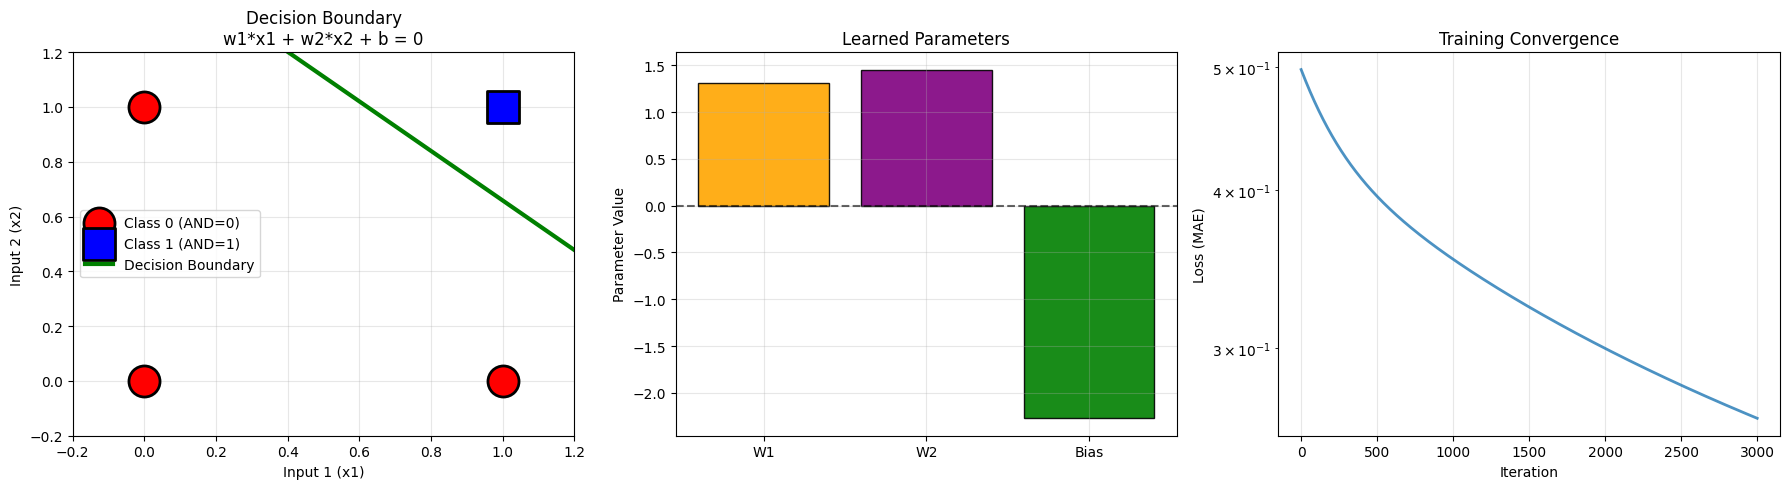


DECISION BOUNDARY VERIFICATION:
Equation: (1.315)*x1 + (1.454)*x2 + (-2.272) = 0
Solved for x2: x2 = (-1.315*x1 - (-2.272)) / 1.454

Point positions relative to boundary:
[0, 0]: -2.272044 → Below (Class 0)
[0, 1]: -0.818019 → Below (Class 0)
[1, 0]: -0.957243 → Below (Class 0)
[1, 1]: 0.496782 → Above (Class 1)


In [ ]:
#AND WITH TRAINED WEIGHTS
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
input_size = 2
learning_rate = 0.01
iterations = 3000
print_interval = 1000

# AND dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [0], [0], [1]])

# Initialize
np.random.seed(42)
weights = np.random.uniform(-1, 1, (input_size, 1))
bias = np.array([[0.0]])

print("Initial Weights + Bias:")
print(f"Weights: {weights.flatten()}")
print(f"Bias: {bias[0,0]:.3f}")

# Activation and derivatives
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(output):
    # derivative w.r.t. output (sigmoid(output_input))
    return output * (1 - output)

def predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    return sigmoid(linear)

# Training loop (single neuron)
print("\nTraining Single Perceptron (AND Gate)...")
loss_history = []

for iteration in range(iterations):
    linear_output = np.dot(X, weights) + bias            # shape (4,1)
    output = sigmoid(linear_output)                      # shape (4,1)
    error = y - output                                   # shape (4,1)
    d_output = error * sigmoid_derivative(output)        # shape (4,1)

    # Gradient descent parameter update
    weights += learning_rate * np.dot(X.T, d_output)     # (2,4) x (4,1) -> (2,1)
    bias += learning_rate * np.sum(d_output, axis=0, keepdims=True)  # (1,1)

    current_loss = np.mean(np.abs(error))                # MAE
    loss_history.append(current_loss)

    if iteration % print_interval == 0:
        print(f"Iteration {iteration:4d}: Loss = {current_loss:.6f}")

print("\nTraining Complete!")
print(f"Final Weights: W1={weights[0,0]:.3f}, W2={weights[1,0]:.3f}")
print(f"Final Bias: {bias[0,0]:.3f}")

# Final predictions
final_predictions = predict(X, weights, bias)

print("\nPredictions (AND Gate):")
for i in range(len(X)):
    pred_prob = final_predictions[i, 0]
    pred_class = 1 if pred_prob > 0.5 else 0
    print(f"Input: [{X[i,0]:.0f}, {X[i,1]:.0f}] → Pred: {pred_prob:.3f} ({pred_class})")

# Visualization
plt.figure(figsize=(18, 5))

# Subplot 1: decision boundary & points
plt.subplot(1, 3, 1)
plt.scatter(X[y.flatten() == 0, 0], X[y.flatten() == 0, 1],
            s=500, marker='o', edgecolors='black', linewidth=2, label='Class 0 (AND=0)', color='red', zorder=3)
plt.scatter(X[y.flatten() == 1, 0], X[y.flatten() == 1, 1],
            s=500, marker='s', edgecolors='black', linewidth=2, label='Class 1 (AND=1)', color='blue', zorder=4)

w1, w2 = weights[0,0], weights[1,0]
b = bias[0,0]
x1_boundary = np.linspace(-0.2, 1.2, 200)
if abs(w2) > 1e-8:
    x2_boundary = (-w1 * x1_boundary - b) / w2
    plt.plot(x1_boundary, x2_boundary, 'g-', linewidth=3, label='Decision Boundary', zorder=2)
else:
    # vertical boundary
    plt.axvline(x=-b/w1, color='g', linewidth=3, label='Decision Boundary')

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel('Input 1 (x1)')
plt.ylabel('Input 2 (x2)')
plt.title('Decision Boundary\nw1*x1 + w2*x2 + b = 0')
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 2: learned parameters
plt.subplot(1, 3, 2)
params = ['W1', 'W2', 'Bias']
values = [w1, w2, b]
plt.bar(params, values, color=['orange', 'purple', 'green'], alpha=0.9, edgecolor='black')
plt.ylabel('Parameter Value')
plt.title('Learned Parameters')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.6)
plt.grid(True, alpha=0.3)

# Subplot 3: loss curve
plt.subplot(1, 3, 3)
plt.semilogy(loss_history, linewidth=2, alpha=0.8)
plt.xlabel('Iteration')
plt.ylabel('Loss (MAE)')
plt.title('Training Convergence')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verification prints
print(f"\nDECISION BOUNDARY VERIFICATION:")
print(f"Equation: ({w1:.3f})*x1 + ({w2:.3f})*x2 + ({b:.3f}) = 0")
if abs(w2) > 1e-8:
    print(f"Solved for x2: x2 = (-{w1:.3f}*x1 - ({b:.3f})) / {w2:.3f}")
else:
    print("Vertical boundary (w2 approximately 0).")

print("\nPoint positions relative to boundary:")
for i in range(len(X)):
    point_value = w1 * X[i, 0] + w2 * X[i, 1] + b
    side = "Above (Class 1)" if point_value > 0 else "Below (Class 0)"
    print(f"[{X[i,0]:.0f}, {X[i,1]:.0f}]: {point_value:.6f} → {side}")


Bias is 0.0
Initial Weights + Bias:
Weights: [-0.25091976  0.90142861]
Bias: 0.000

Training Single Perceptron (OR Gate)...
Iteration    0: Loss = 0.4235
Iteration 1000: Loss = 0.2693
Iteration 2000: Loss = 0.2290

Training Complete!
Final Weights: W1=1.818, W2=2.053
Final Bias: -0.531

Predictions (OR Gate):
Input: [0, 0] → Pred: 0.370 (0)
Input: [0, 1] → Pred: 0.821 (1)
Input: [1, 0] → Pred: 0.784 (1)
Input: [1, 1] → Pred: 0.966 (1)


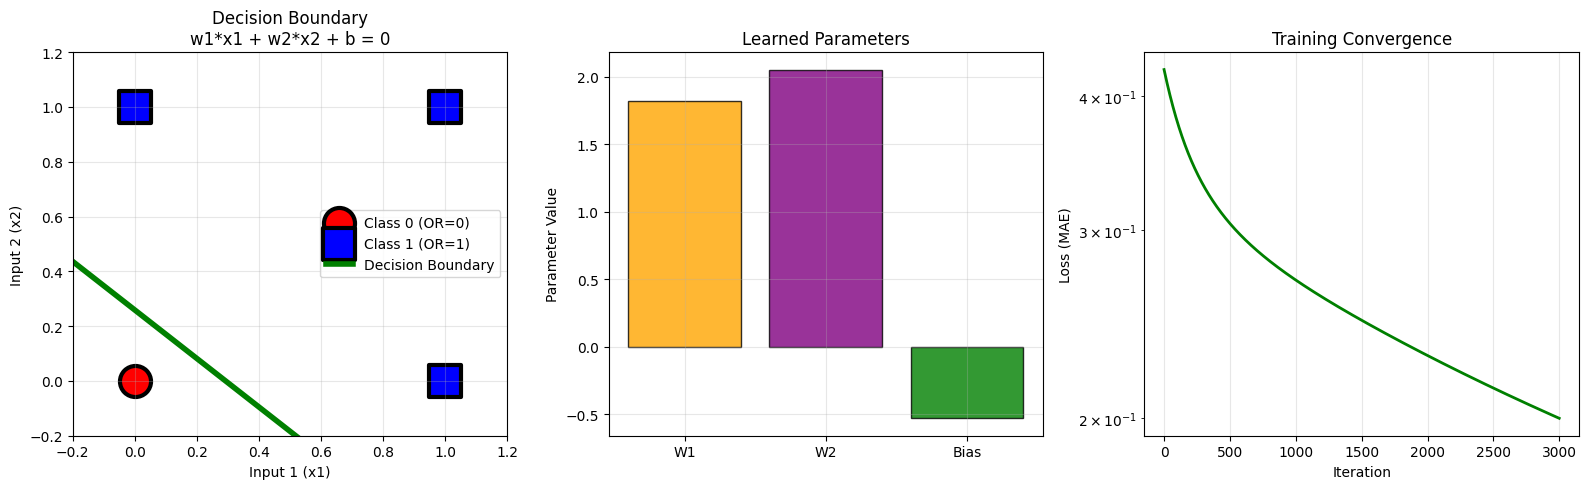


DECISION BOUNDARY VERIFICATION:
Equation: 1.818*x1 + 2.053*x2 + -0.531 = 0
Solved: x2 = (-1.818*x1 - -0.531) / 2.053

Point positions relative to boundary:
[0, 0] → -0.531 → Below (Class 0)
[0, 1] → 1.522 → Above (Class 1)
[1, 0] → 1.287 → Above (Class 1)
[1, 1] → 3.339 → Above (Class 1)


In [ ]:
#OR WITH TRAINED WEIGHTS
import numpy as np
import matplotlib.pyplot as plt

# Hyperparameters
input_size = 2
learning_rate = 0.01
iterations = 3000
print_interval = 1000

# OR Gate Dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [1]])

# Initialize weights
np.random.seed(42)
weights = np.random.uniform(-1, 1, (input_size, 1))   # shape (2,1)
bias = np.array([[0.0]])

print("Bias is", bias[0, 0])
print("Initial Weights + Bias:")
print(f"Weights: {weights.flatten()}")
print(f"Bias: {bias[0, 0]:.3f}")


# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))


def sigmoid_derivative(x):
    return x * (1 - x)


def predict(X, weights, bias):
    linear = np.dot(X, weights) + bias
    return sigmoid(linear)


print("\nTraining Single Perceptron (OR Gate)...")
loss_history = []

for iteration in range(iterations):
    linear_output = np.dot(X, weights) + bias
    output = sigmoid(linear_output)

    error = y - output
    d_output = error * sigmoid_derivative(output)

    weights += learning_rate * np.dot(X.T, d_output)
    bias += learning_rate * np.sum(d_output, axis=0, keepdims=True)

    current_loss = np.mean(np.abs(error))
    loss_history.append(current_loss)

    if iteration % print_interval == 0:
        print(f"Iteration {iteration:4d}: Loss = {current_loss:.4f}")

print("\nTraining Complete!")
print(f"Final Weights: W1={weights[0][0]:.3f}, W2={weights[1][0]:.3f}")
print(f"Final Bias: {bias[0][0]:.3f}")

# Predictions
final_predictions = predict(X, weights, bias)
print("\nPredictions (OR Gate):")
for i in range(len(X)):
    pred_class = 1 if final_predictions[i][0] > 0.5 else 0
    print(f"Input: [{X[i][0]}, {X[i][1]}] → Pred: {final_predictions[i][0]:.3f} ({pred_class})")

# --- Plotting ---
plt.figure(figsize=(16, 5))

# Subplot 1 — Decision Boundary
plt.subplot(1, 3, 1)
plt.scatter(X[y.flatten()==0, 0], X[y.flatten()==0, 1],
            s=500, c='red', marker='o', edgecolors='black', linewidth=3, label='Class 0 (OR=0)')
plt.scatter(X[y.flatten()==1, 0], X[y.flatten()==1, 1],
            s=500, c='blue', marker='s', edgecolors='black', linewidth=3, label='Class 1 (OR=1)')

w1, w2 = weights[0,0], weights[1,0]
b = bias[0,0]

x1_boundary = np.linspace(-0.2, 1.2, 100)
if abs(w2) > 1e-6:
    x2_boundary = (-w1 * x1_boundary - b) / w2
    plt.plot(x1_boundary, x2_boundary, 'g-', linewidth=4, label='Decision Boundary')
else:
    plt.axvline(x=-b / w1, color='g', linewidth=4, label='Decision Boundary')

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("Input 1 (x1)")
plt.ylabel("Input 2 (x2)")
plt.title("Decision Boundary\nw1*x1 + w2*x2 + b = 0")
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 2 — Learned Parameters
plt.subplot(1, 3, 2)
params = ["W1", "W2", "Bias"]
values = [w1, w2, b]
plt.bar(params, values, color=['orange', 'purple', 'green'], alpha=0.8, edgecolor='black')
plt.ylabel("Parameter Value")
plt.title("Learned Parameters")
plt.grid(True, alpha=0.3)

# Subplot 3 — Loss Curve
plt.subplot(1, 3, 3)
plt.semilogy(loss_history, 'g-', linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Loss (MAE)")
plt.title("Training Convergence")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Verification Section
print("\nDECISION BOUNDARY VERIFICATION:")
print(f"Equation: {w1:.3f}*x1 + {w2:.3f}*x2 + {b:.3f} = 0")
print(f"Solved: x2 = (-{w1:.3f}*x1 - {b:.3f}) / {w2:.3f}")

print("\nPoint positions relative to boundary:")
for i in range(len(X)):
    point_value = w1*X[i,0] + w2*X[i,1] + b
    side = "Above (Class 1)" if point_value >= 0 else "Below (Class 0)"
    print(f"[{X[i,0]}, {X[i,1]}] → {point_value:.3f} → {side}")


In [ ]:
# XOR GATE USING RANDOM INITIALIZATION (NO DOT PRODUCT ANYWHERE)

import numpy as np

learning_rate = 0.1
iterations = 20000
print_interval = 5000

X1 = np.array([
    [0, 0],
    [0, 1]
])

X2 = np.array([
    [1, 0],
    [1, 1]
])

# Combine for training (logically still split)
X = np.vstack((X1, X2))

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# Random initialization
W1 = np.random.uniform(-1, 1, (2, 2))   # Input → Hidden
b1 = np.random.uniform(-1, 1, (1, 2))   # Hidden bias

W2 = np.random.uniform(-1, 1, (2, 1))   # Hidden → Output
b2 = np.random.uniform(-1, 1, (1, 1))   # Output bias

print("Initial Parameters:")
print("W1:\n", W1)
print("b1:\n", b1)
print("W2:\n", W2)
print("b2:\n", b2)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(x):
    return x * (1 - x)

print("\nTraining XOR Neural Network...")

# Training loop
for iteration in range(iterations):

    # ---------- FORWARD PASS (MANUAL) ----------
    a1 = np.zeros((4, 2))
    output = np.zeros((4, 1))

    for i in range(4):
        x1, x2 = X[i]

        z1_1 = x1*W1[0,0] + x2*W1[1,0] + b1[0,0]
        z1_2 = x1*W1[0,1] + x2*W1[1,1] + b1[0,1]

        a1[i,0] = sigmoid(z1_1)
        a1[i,1] = sigmoid(z1_2)

        z2 = a1[i,0]*W2[0,0] + a1[i,1]*W2[1,0] + b2[0,0]
        output[i,0] = sigmoid(z2)

    # ---------- LOSS ----------
    error = y - output

    # ---------- BACKPROPAGATION (MANUAL) ----------
    d_output = error * sigmoid_derivative(output)
    d_hidden = np.zeros((4,2))

    for i in range(4):
        d_hidden[i,0] = d_output[i,0] * W2[0,0] * sigmoid_derivative(a1[i,0])
        d_hidden[i,1] = d_output[i,0] * W2[1,0] * sigmoid_derivative(a1[i,1])

    # ---------- UPDATE OUTPUT LAYER ----------
    for i in range(4):
        W2[0,0] += learning_rate * a1[i,0] * d_output[i,0]
        W2[1,0] += learning_rate * a1[i,1] * d_output[i,0]
        b2[0,0] += learning_rate * d_output[i,0]

    # ---------- UPDATE HIDDEN LAYER ----------
    for i in range(4):
        x1, x2 = X[i]
        W1[0,0] += learning_rate * x1 * d_hidden[i,0]
        W1[1,0] += learning_rate * x2 * d_hidden[i,0]
        W1[0,1] += learning_rate * x1 * d_hidden[i,1]
        W1[1,1] += learning_rate * x2 * d_hidden[i,1]

        b1[0,0] += learning_rate * d_hidden[i,0]
        b1[0,1] += learning_rate * d_hidden[i,1]

    if iteration % print_interval == 0:
        loss = np.mean(np.abs(error))
        print(f"Iteration {iteration:5d}: Loss = {loss:.4f}")

print("\nTraining Complete!")

print("\nFinal Learned Parameters:")
print("W1:\n", W1)
print("b1:\n", b1)
print("W2:\n", W2)
print("b2:\n", b2)

# ---------- FINAL PREDICTIONS ----------
print("\nPredictions (XOR Gate):")

for i in range(4):
    x1, x2 = X[i]

    h1 = sigmoid(x1*W1[0,0] + x2*W1[1,0] + b1[0,0])
    h2 = sigmoid(x1*W1[0,1] + x2*W1[1,1] + b1[0,1])

    out = sigmoid(h1*W2[0,0] + h2*W2[1,0] + b2[0,0])
    pred = 1 if out > 0.5 else 0

    print(f"Input: {X[i]} → Pred: {out:.3f} ({pred})")

# ---------- DECISION BOUNDARY ----------
print("\nDECISION BOUNDARY VERIFICATION:")

w21 = W2[0,0]
w22 = W2[1,0]
b_out = b2[0,0]

print(f"Equation: {w21:.3f}*h1 + {w22:.3f}*h2 + {b_out:.3f} = 0")
print(f"Solved: h2 = (-({w21:.3f}*h1) - {b_out:.3f}) / {w22:.3f}")

print("\nPoint positions relative to boundary:")

for i in range(4):
    x1, x2 = X[i]

    h1 = sigmoid(x1*W1[0,0] + x2*W1[1,0] + b1[0,0])
    h2 = sigmoid(x1*W1[0,1] + x2*W1[1,1] + b1[0,1])

    value = w21*h1 + w22*h2 + b_out
    side = "Above (Class 1)" if value >= 0 else "Below (Class 0)"

    print(f"{X[i].tolist()} → {value:.3f} → {side}")


Initial Parameters:
W1:
 [[ 0.9398197   0.66488528]
 [-0.57532178 -0.63635007]]
b1:
 [[-0.63319098 -0.39151551]]
W2:
 [[ 0.04951286]
 [-0.13610996]]
b2:
 [[-0.41754172]]

Training XOR Neural Network...
Iteration     0: Loss = 0.5001
Iteration  5000: Loss = 0.1251
Iteration 10000: Loss = 0.0507
Iteration 15000: Loss = 0.0364

Training Complete!

Final Learned Parameters:
W1:
 [[ 5.81477782  5.54539572]
 [-5.85522347 -5.30728189]]
b1:
 [[-3.20891644  2.64694311]]
W2:
 [[ 8.48810019]
 [-8.22135366]]
b2:
 [[3.87096655]]

Predictions (XOR Gate):
Input: [0 0] → Pred: 0.030 (0)
Input: [0 1] → Pred: 0.966 (1)
Input: [1 0] → Pred: 0.972 (1)
Input: [1 1] → Pred: 0.027 (0)

DECISION BOUNDARY VERIFICATION:
Equation: 8.488*h1 + -8.221*h2 + 3.871 = 0
Solved: h2 = (-(8.488*h1) - 3.871) / -8.221

Point positions relative to boundary:
[0, 0] → -3.477 → Below (Class 0)
[0, 1] → 3.335 → Above (Class 1)
[1, 0] → 3.556 → Above (Class 1)
[1, 1] → -3.598 → Below (Class 0)


In [ ]:
# XOR GATE USING RANDOM INITIALIZATION (FIXED FOR TWO ARRAYS)

import numpy as np

learning_rate = 0.1
iterations = 20000
print_interval = 5000

# Split input arrays
X1 = np.array([
    [0, 0],
    [0, 1],
])

X2 = np.array([
    [1, 0],
    [1, 1]
])

# Combine into single input matrix
X = np.vstack((X1, X2))

y = np.array([
    [0],
    [1],
    [1],
    [0]
])

W1 = np.random.uniform(-1, 1, (2, 2))
b1 = np.random.uniform(-1, 1, (1, 2))

W2 = np.random.uniform(-1, 1, (2, 1))
b2 = np.random.uniform(-1, 1, (1, 1))

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

def sigmoid_derivative(x):
    return x * (1 - x)

for iteration in range(iterations):

    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)

    z2 = np.dot(a1, W2) + b2
    output = sigmoid(z2)

    error = y - output

    d_output = error * sigmoid_derivative(output)
    d_hidden = np.dot(d_output, W2.T) * sigmoid_derivative(a1)

    W2 += learning_rate * np.dot(a1.T, d_output)
    b2 += learning_rate * np.sum(d_output, axis=0, keepdims=True)

    W1 += learning_rate * np.dot(X.T, d_hidden)
    b1 += learning_rate * np.sum(d_hidden, axis=0, keepdims=True)

print("\nPredictions (XOR Gate):")
final_output = sigmoid(np.dot(sigmoid(np.dot(X, W1) + b1), W2) + b2)

for i in range(len(X)):
    pred = 1 if final_output[i][0] > 0.5 else 0
    print(f"Input: {X[i]} → {final_output[i][0]:.3f} ({pred})")



Predictions (XOR Gate):
Input: [0 0] → 0.061 (0)
Input: [0 1] → 0.935 (1)
Input: [1 0] → 0.935 (1)
Input: [1 1] → 0.080 (0)


In [ ]:
# and gate with random insilization (sir code)
import numpy as np

# Input values
x1 = np.array([0, 0, 1, 1])
x2 = np.array([0, 1, 0, 1])
# Target output (AND gate)
t = np.array([0, 0, 0, 1])

m = len(t)

# Hyperparameters
max_iter = 4000
learn_rate = 0.1

# Random initialization of weights
w1 = np.random.uniform(-1, 1) * 0.2
w2 = np.random.uniform(-1, 1) * 0.2
b = 0

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Sigmoid derivative
def sigmoid_derivative(s):
    return s * (1 - s)

# Training loop
for _ in range(max_iter):

    dw1 = 0
    dw2 = 0
    db = 0

    for i in range(m):
        z = x1[i] * w1 + x2[i] * w2 + b
        y = sigmoid(z)

        error = t[i] - y
        d = error * sigmoid_derivative(y)

        dw1 += d * x1[i]
        dw2 += d * x2[i]
        db  += d

    # Update weights and bias
    w1 += learn_rate * (dw1 / m)
    w2 += learn_rate * (dw2 / m)
    b  += learn_rate * (db / m)

# Final weights
print("Final weights and bias:")
print("w1 =", w1)
print("w2 =", w2)
print("b  =", b)

# Prediction
print("\nPredictions:")
for i in range(m):
    z = x1[i] * w1 + x2[i] * w2 + b
    y = sigmoid(z)
    print(x1[i], x2[i], "->", round(y))

Final weights and bias:
w1 = 2.6032824278310516
w2 = 2.603810437284177
b  = -4.031422839919969

Predictions:
0 0 -> 0
0 1 -> 0
1 0 -> 0
1 1 -> 1


In [ ]:
# or gate with random inisilization(sir code)
import numpy as np

# Input values
x1 = np.array([0, 0, 1, 1])
x2 = np.array([0, 1, 0, 1])

# Target output (OR gate)
t = np.array([0, 1, 1, 1])

m = len(t)

# Hyperparameters
max_iter = 4000
learn_rate = 0.1

# Random initialization of weights
w1 = np.random.uniform(-1, 1) * 0.2
w2 = np.random.uniform(-1, 1) * 0.2
b = 0

# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Sigmoid derivative
def sigmoid_derivative(s):
    return s * (1 - s)

# Training loop
for _ in range(max_iter):

    dw1 = 0
    dw2 = 0
    db = 0

    for i in range(m):
        z = x1[i] * w1 + x2[i] * w2 + b
        y = sigmoid(z)

        error = t[i] - y
        d = error * sigmoid_derivative(y)

        dw1 += d * x1[i]
        dw2 += d * x2[i]
        db  += d

    # Update weights and bias
    w1 += learn_rate * (dw1 / m)
    w2 += learn_rate * (dw2 / m)
    b  += learn_rate * (db / m)

# Final weights
print("Final weights and bias:")
print("w1 =", w1)
print("w2 =", w2)
print("b  =", b)

# Prediction
print("\nPredictions:")
for i in range(m):
    z = x1[i] * w1 + x2[i] * w2 + b
    y = sigmoid(z)
    print(x1[i], x2[i], "->", round(y))

Final weights and bias:
w1 = 3.2872634341809692
w2 = 3.286438557288549
b  = -1.3333010795036497

Predictions:
0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 1


In [ ]:
#XOR gate with random initilization (sir code)

import numpy as np

x1 = np.array([0, 0, 1, 1])
x2 = np.array([0, 1, 0, 1])

t = np.array([0, 1, 1, 0])

m = len(t)

max_iter = 90000
learn_rate = 0.3

w1 = np.random.uniform(-1, 1) * 0.2
w2 = np.random.uniform(-1, 1) * 0.2
w3 = np.random.uniform(-1, 1) * 0.2
w4 = np.random.uniform(-1, 1) * 0.2
w5 = np.random.uniform(-1, 1) * 0.2
w6 = np.random.uniform(-1, 1) * 0.2
b1 = 0.0
b2 = 0.0
b3 = 0.0
losses = []

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(s):
    return s * (1 - s)

for _ in range(max_iter):

    dw1 = dw2 = dw3 = dw4 = dw5 = dw6 = 0.0
    db1 = db2 = db3 = 0.0
    mse = 0.0

    for i in range(m):

        zh1 = x1[i] * w1 + x2[i] * w2 + b1
        zh2 = x1[i] * w3 + x2[i] * w4 + b2

        h1 = sigmoid(zh1)
        h2 = sigmoid(zh2)

        zo = h1 * w5 + h2 * w6 + b3
        y  = sigmoid(zo)

        error = y-t[i]

        mse += (t[i]-y)**2

        d_out = error * sigmoid_derivative(y)

        dw5 += d_out * h1
        dw6 += d_out * h2
        db3 += d_out

        d_h1 = d_out * w5 * sigmoid_derivative(h1)
        d_h2 = d_out * w6 * sigmoid_derivative(h2)

        dw1 += d_h1 * x1[i]
        dw2 += d_h1 * x2[i]
        dw3 += d_h2 * x1[i]
        dw4 += d_h2 * x2[i]

        db1 += d_h1
        db2 += d_h2

    w1 -= learn_rate * (dw1 / m)
    w2 -= learn_rate * (dw2 / m)
    w3 -= learn_rate * (dw3 / m)
    w4 -= learn_rate * (dw4 / m)
    w5 -= learn_rate * (dw5 / m)
    w6 -= learn_rate * (dw6 / m)

    b1 -= learn_rate * (db1 / m)
    b2 -= learn_rate * (db2 / m)
    b3 -= learn_rate * (db3 / m)

    losses.append(mse/m)


print("Final weights:")
print(w1, w2, w3, w4, w5, w6)
print("Biases:", b1, b2, b3)

print("\nPredictions:")
final_pred=[]
for j in range(m):
  h1 = sigmoid(x1[j] * w1 + x2[j] * w2 + b1)
  h2 = sigmoid(x1[j]* w3 + x2[j] * w4 + b2)
  o  = sigmoid(h1 * w5 + h2 * w6 + b3)
  final_pred.append(o)

for j in range(m):
  print(x1[j] , " " , x2[j] , " ", final_pred[j].round())

Final weights:
0.08355505492743637 0.06600497318427549 0.10345076912905875 -0.09589698076867037 -0.059912931077293466 0.06446807686951657
Biases: -0.09024105501206453 -0.06117566471501782 -0.0015790783592678258

Predictions:
0   0   1.0
0   1   0.0
1   0   1.0
1   1   0.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
The size of train_x is: (60000, 28, 28)
The size of train_y is: (60000,)
The size of test_x is: (10000, 28, 28)
The size of test_y is: (10000,)
[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 20/20 - loss: 0.007528217509388924 - accuracy: 0.9975333213806152 - val_loss: 0.053584471344947815 - val_accuracy: 0.9857000112533569


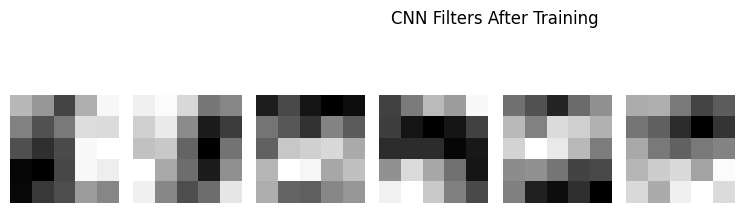

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9812 - loss: 0.0689
Test Loss: 0.053584471344947815
Test accuracy: 0.9857000112533569


In [ ]:
#lenet 5
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AvgPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical, plot_model
import matplotlib.pyplot as plt

# Loading the dataset and performing splitting¶
(train_x, train_y), (test_x, test_y) = mnist.load_data()

#Checking the sizes of train and test split
print("The size of train_x is: {}".format(train_x.shape))
print("The size of train_y is: {}".format(train_y.shape))
print("The size of test_x is: {}".format(test_x.shape))
print("The size of test_y is: {}".format(test_y.shape))


# Peforming reshaping operations- Converting into 4-D¶

train_x = train_x.reshape(train_x.shape[0], 28, 28, 1)
test_x = test_x.reshape(test_x.shape[0], 28, 28, 1)


# Normalizing the values of image- converting in between 0 and 1¶
train_x = train_x/255.0
test_x = test_x/255.0


# One-hot encoding the labels
train_y = to_categorical(train_y, num_classes=10)

test_y = to_categorical(test_y, num_classes=10)
print(test_y)


# Building the Model Architecture¶


model = Sequential()

model.add(Conv2D(filters=6,
                 kernel_size=(5,5),
                 padding='valid',
                 input_shape=(28,28,1),
                 activation='tanh'))
model.add(AvgPool2D(pool_size=(2,2)))
model.add(Conv2D(filters=16,
                 kernel_size=(5,5),
                 padding='valid',
                 activation='tanh'))
model.add(AvgPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))
model.summary()

# Compiling the model
model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])

# Fitting the model
# Fitting the model (no batch output)
history = model.fit(
    train_x, train_y,
    batch_size=128,
    epochs=20,
    validation_data=(test_x, test_y),
    verbose=0   # completely suppress training output
)

# Print only the last epoch result
print("Epoch 20/20 - loss:", history.history['loss'][-1],
      "- accuracy:", history.history['accuracy'][-1],
      "- val_loss:", history.history['val_loss'][-1],
      "- val_accuracy:", history.history['val_accuracy'][-1])


conv_layer = model.layers[0]
filters = conv_layer.get_weights()[0]

plt.figure(figsize=(10, 10))
for i in range(6):
    plt.subplot(4, 8, i+1)
    plt.imshow(filters[:, :, 0, i], cmap='gray')
    plt.axis('off')
plt.suptitle('CNN Filters After Training')
plt.tight_layout()
plt.show()


#Finding the loss and accuracy of the model
score = model.evaluate(test_x, test_y)

print('Test Loss:', score[0])
print('Test accuracy:', score[1])

In [ ]:
#alnet

# Import the necessary Libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical, plot_model


## Loading the dataset and performing splitting

(train_x, train_y), (test_x, test_y) = mnist.load_data()


## Checking the sizes of train and test split

print("The size of train_x is: {}".format(train_x.shape))
print("The size of train_y is: {}".format(train_y.shape))

print("The size of test_x is: {}".format(test_x.shape))
print("The size of test_y is: {}".format(test_y.shape))


## Peforming reshaping operations- Converting into 4-D



train_x = train_x.reshape(train_x.shape[0], 28, 28, 1)
test_x = test_x.reshape(test_x.shape[0], 28, 28, 1)




## Normalizing the values of image- converting in between 0 and 1
train_x = train_x/255.0
test_x = test_x/255.0


## One-hot encoding the labels

train_y = to_categorical(train_y, num_classes=10)
test_y = to_categorical(test_y, num_classes=10)


## The Model
model = Sequential()

model.add(Conv2D(96, (5,5), strides=4, padding='valid',
                 input_shape=(28,28,1), activation='relu'))

model.add(MaxPool2D((2,2), strides=2))

model.add(Conv2D(256, (3,3), padding='same', activation='relu'))

model.add(MaxPool2D((2,2), strides=1))

model.add(Conv2D(384, (1,1), padding='same', activation='relu'))

model.add(Conv2D(384, (1,1), padding='same', activation='relu'))

model.add(Conv2D(256, (1,1), padding='same', activation='relu'))

model.add(Flatten())

model.add(Dense(512, activation='relu'))

model.add(Dense(512, activation='relu'))

model.add(Dense(10, activation='softmax'))
model.summary()


## Compiling the model
model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])


## Fitting the model
history = model.fit(
    train_x, train_y,
    batch_size=128,
    epochs=1,
    validation_data=(test_x, test_y),
    verbose=0   # completely suppress training output
)

# Print only the last epoch result
print("Epoch 20/20 - loss:", history.history['loss'][-1],
      "- accuracy:", history.history['accuracy'][-1],
      "- val_loss:", history.history['val_loss'][-1],
      "- val_accuracy:", history.history['val_accuracy'][-1])


## Finding the loss and accuracy of the model
score = model.evaluate(test_x, test_y)

print('Test Loss:', score[0])
print('Test accuracy:', score[1])

The size of train_x is: (60000, 28, 28)
The size of train_y is: (60000,)
The size of test_x is: (10000, 28, 28)
The size of test_y is: (10000,)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 6, 6, 96)       │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 3, 3, 256)      │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 2, 2, 384)      │        98,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 2, 2, 384)      │       147,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 2, 2, 256)      │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,361,610 (5.19 MB)

 Trainable params: 1,361,610 (5.19 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 20/20 - loss: 0.35987553000450134 - accuracy: 0.8754000067710876 - val_loss: 0.1384703814983368 - val_accuracy: 0.9555000066757202
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9454 - loss: 0.1680
Test Loss: 0.1384703814983368
Test accuracy: 0.9555000066757202


In [ ]:
#VGG
# Import the necessary Libraries
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical, plot_model


## Loading the dataset and performing splitting

(train_x, train_y), (test_x, test_y) = mnist.load_data()


## Checking the sizes of train and test split

print("The size of train_x is: {}".format(train_x.shape))
print("The size of train_y is: {}".format(train_y.shape))

print("The size of test_x is: {}".format(test_x.shape))
print("The size of test_y is: {}".format(test_y.shape))


## Peforming reshaping operations- Converting into 4-D


train_x = train_x.reshape(train_x.shape[0], 28, 28, 1)
test_x = test_x.reshape(test_x.shape[0], 28, 28, 1)




## Normalizing the values of image- converting in between 0 and 1
train_x = train_x/255.0
test_x = test_x/255.0


## One-hot encoding the labels

train_y = to_categorical(train_y, num_classes=10)
test_y = to_categorical(test_y, num_classes=10)

# VGG-model for 28x28 MNIST
model = Sequential()

# Block 1: 28x28 -> 14x14
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28, 28, 1)))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2), strides=2))

# Block 2: 14x14 -> 7x7
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2), strides=2))

# Block 3: 7x7 -> 3x3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2,2), strides=2))

# Flatten and Optimized FC layers
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax')) # 10 classes for MNIST

model.summary()

## Compiling the model
model.compile(loss='categorical_crossentropy', optimizer=Adam(), metrics=['accuracy'])


## Fitting the model
history = model.fit(
    train_x, train_y,
    batch_size=128,
    epochs=1,
    validation_data=(test_x, test_y),
    verbose=0   # completely suppress training output
)

# Print only the last epoch result
print("Epoch 20/20 - loss:", history.history['loss'][-1],
      "- accuracy:", history.history['accuracy'][-1],
      "- val_loss:", history.history['val_loss'][-1],
      "- val_accuracy:", history.history['val_accuracy'][-1])


## Finding the loss and accuracy of the model
score = model.evaluate(test_x, test_y)

print('Test Loss:', score[0])
print('Test accuracy:', score[1])


The size of train_x is: (60000, 28, 28)
The size of train_y is: (60000,)
The size of test_x is: (10000, 28, 28)
The size of test_y is: (10000,)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 584,170 (2.23 MB)

 Trainable params: 584,170 (2.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 20/20 - loss: 0.16532602906227112 - accuracy: 0.9487000107765198 - val_loss: 0.043824728578329086 - val_accuracy: 0.9855999946594238
101/313 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.9821 - loss: 0.0586

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 20/20 - loss: 0.10979098081588745 - accuracy: 0.9646499752998352 - val_loss: 0.4768434166908264 - val_accuracy: 0.828000009059906
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8208 - loss: 0.5066
Test Accuracy: 0.8250799775123596


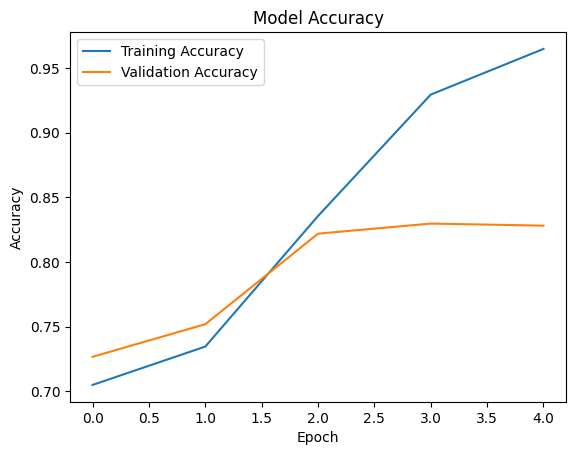

In [ ]:
############
# RNN for Text classification
#
###########
# Import required libraries
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt

# Load IMDB dataset (top 10,000 most frequent words)
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Pad sequences so all reviews have the same length
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# Build the RNN model
model = Sequential()

# Embedding layer converts word indexes into dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=32))

# Simple RNN layer for sequential text processing
model.add(SimpleRNN(32))

# Output layer for binary classification (positive / negative)
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)
print("Epoch 20/20 - loss:", history.history['loss'][-1],
      "- accuracy:", history.history['accuracy'][-1],
      "- val_loss:", history.history['val_loss'][-1],
      "- val_accuracy:", history.history['val_accuracy'][-1])

# Evaluate model on test data
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

# Plot training accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

Epoch 20/20 - loss: 0.4475087821483612 - accuracy: 0.7867500185966492 - val_loss: 0.3450721800327301 - val_accuracy: 0.8514000177383423
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8556 - loss: 0.3437
Test Accuracy: 0.8565199971199036


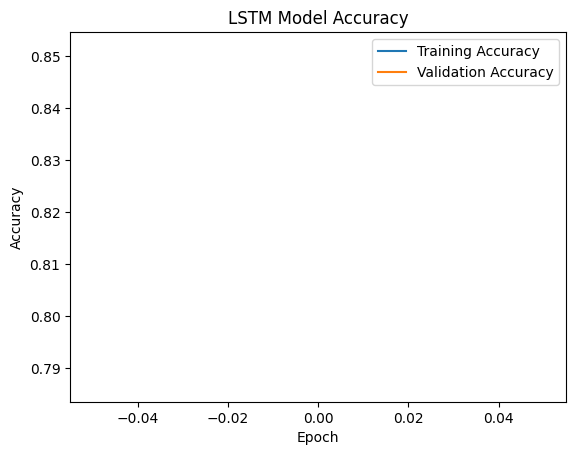

In [ ]:
############
# LSTM for Text classification
#
###########
# Import required libraries
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt

# Load IMDB dataset (keep top 10,000 frequent words)
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Make all reviews the same length
max_length = 200
x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

# Build the LSTM model
model = Sequential()

# Embedding layer converts word numbers into dense vectors
model.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length))

# LSTM layer for learning long-term text patterns
model.add(LSTM(64))

# Output layer for binary sentiment classification
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=1,
    batch_size=64,
    validation_split=0.2,
    verbose=0
)
print("Epoch 20/20 - loss:", history.history['loss'][-1],
      "- accuracy:", history.history['accuracy'][-1],
      "- val_loss:", history.history['val_loss'][-1],
      "- val_accuracy:", history.history['val_accuracy'][-1])


# Evaluate on test data
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)

# Plot training accuracy
plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Model Accuracy")
plt.show()